# Pipeline de pre-procesamiento de Datos
### Dataset: `kidney_disease.csv` (diagnóstico de enfermedad renal crónica)

En este notebook se encontrará: 
1. Mini-EDA (tipos de variable, datos faltantes, rangos numéricos, categorías).
2. Diseño e implementación de un pipeline de pre-procesamiento con `scikit-learn`,
   incluyendo un **Custom Transformer** construido con `FunctionTransformer`.
3. Validación del pipeline entrenando un modelo simple de clasificación.

El dataset original (`kidney_disease.csv`, fuente: Kaggle, *Chronic Kidney Disease Dataset*)
contiene 400 pacientes y 24 variables clínicas más el identificador y la variable objetivo
(`classification`). Se selecciona un subconjunto representativo de 7 variables predictoras que conserva la mezcla numérica/categórica
(nominal y ordinal) y la presencia real de datos faltantes exigida por el enunciado.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Carga y vistazo inicial del dataset

In [2]:
df_raw = pd.read_csv("kidney_disease.csv")
print("Dimensiones del dataset original:", df_raw.shape)
df_raw.head()

Dimensiones del dataset original: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
print("Información general del dataset original:")
df_raw.info()

Información general del dataset original:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object

### 2.1 Selección del subconjunto de variables

El dataset trae 26 columnas (`id` + 24 variables clínicas + `classification`), muy por encima
del rango de 5 a 10 variables pedido en la guía. Se seleccionan 7 predictoras que conservan
la heterogeneidad de tipos exigida por el enunciado:

- **Numéricas continuas:** `age` (edad), `bp` (presión arterial), `hemo` (hemoglobina),
  `sc` (creatinina sérica).
- **Categórica nominal:** `rbc` (glóbulos rojos en orina: `normal`/`abnormal`), `dm`
  (diabetes mellitus: `yes`/`no`).
- **Categórica ordinal:** `appet` (apetito del paciente: `poor` < `good`, existe un orden
  clínico natural de peor a mejor estado).
- **Identificador:** `id` — no aporta señal predictiva, se descarta del pipeline.
- **Variable objetivo (target):** `classification` (`ckd` = enfermedad renal crónica,
  `notckd` = sin enfermedad). Es binaria.

In [4]:
cols_usar = ["age", "bp", "hemo", "sc", "rbc", "dm", "appet"]
target = "classification"

df = df_raw[cols_usar + [target]].copy()
print("Dimensiones del subconjunto de trabajo:", df.shape)
df.head()

Dimensiones del subconjunto de trabajo: (400, 8)


,age,bp,hemo,sc,rbc,dm,appet,classification
0,48.0,80.0,15.4,1.2,NaN,yes,good,ckd
1,7.0,50.0,11.3,0.8,NaN,no,good,ckd
2,62.0,80.0,9.6,1.8,normal,yes,poor,ckd
3,48.0,70.0,11.2,3.8,normal,no,poor,ckd
4,51.0,80.0,11.6,1.4,normal,no,good,ckd


In [5]:
num_vars = df[cols_usar].select_dtypes(include=["number"]).columns.tolist()
print("Variables numéricas:", num_vars)

cat_vars = df[cols_usar].select_dtypes(include=["object", "string"]).columns.tolist()
print("Variables categóricas / texto:", cat_vars)

Variables numéricas: ['age', 'bp', 'hemo', 'sc']
Variables categóricas / texto: ['rbc', 'dm', 'appet']


## 3. Datos faltantes

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"faltantes": missing, "% faltantes": missing_pct})

,faltantes,% faltantes
age,9,2.25
bp,12,3.00
hemo,52,13.00
sc,17,4.25
rbc,152,38.00
dm,2,0.50
appet,1,0.25
classification,0,0.00


### 3.1 Estrategia de imputación

Todas las predictoras seleccionadas presentan datos faltantes, desde `sc` (~4%) hasta `rbc`
(~38%, la más incompleta del subconjunto). `classification` no tiene faltantes.

- **`age`, `bp`, `hemo`, `sc` (numéricas):** se imputan con la **mediana**. Es una base de
  datos clínica con posibles valores extremos (p.ej. creatinina muy elevada en pacientes
  graves), por lo que la mediana es más robusta que la media ante esos outliers.
- **`rbc`, `dm` (categóricas nominales):** se imputan con la **moda** (`most_frequent`), la
  estrategia estándar para variables categóricas sin orden. En `rbc`, con ~38% de faltantes,
  la moda sigue siendo razonable porque una de las dos categorías (`normal`) domina
  ampliamente el conjunto.
- **`appet` (categórica ordinal):** también se imputa con la **moda**, preservando después su
  codificación ordinal.
- **`id`:** se descarta del pipeline, no requiere imputación.

## 4. Variables numéricas: rangos y escalamiento

In [7]:
df[["age", "bp", "hemo", "sc"]].describe()

,age,bp,hemo,sc
count,391.000000,388.000000,348.000000,383.000000
mean,51.483376,76.469072,12.526437,3.072454
std,17.169714,13.683637,2.912587,5.741126
min,2.000000,50.000000,3.100000,0.400000
25%,42.000000,70.000000,10.300000,0.900000
50%,55.000000,80.000000,12.650000,1.300000
75%,64.500000,80.000000,15.000000,2.800000
max,90.000000,180.000000,17.800000,76.000000


### 4.1 Rango de valores y estrategia de escalamiento

- **`age`:** de 2 a 90 años, escala habitual de edad humana.
- **`bp`:** de 50 a 180 mmHg, presión arterial diastólica.
- **`hemo`:** de 3.1 a 17.8 g/dL, hemoglobina.
- **`sc`:** de 0.4 a 76 mg/dL, creatinina sérica; su rango es el más disperso de las cuatro
  (media ≈ 3.1, pero con una cola de valores muy altos propios de pacientes con falla renal
  severa).

Las cuatro variables tienen unidades y escalas completamente distintas (años, mmHg, g/dL,
mg/dL), y el modelo de referencia usado más adelante es una **Regresión Logística**, sensible
a la escala de las variables. Por eso se aplica `StandardScaler` después de imputar, para que
ninguna variable domine el ajuste del modelo solo por tener números más grandes.

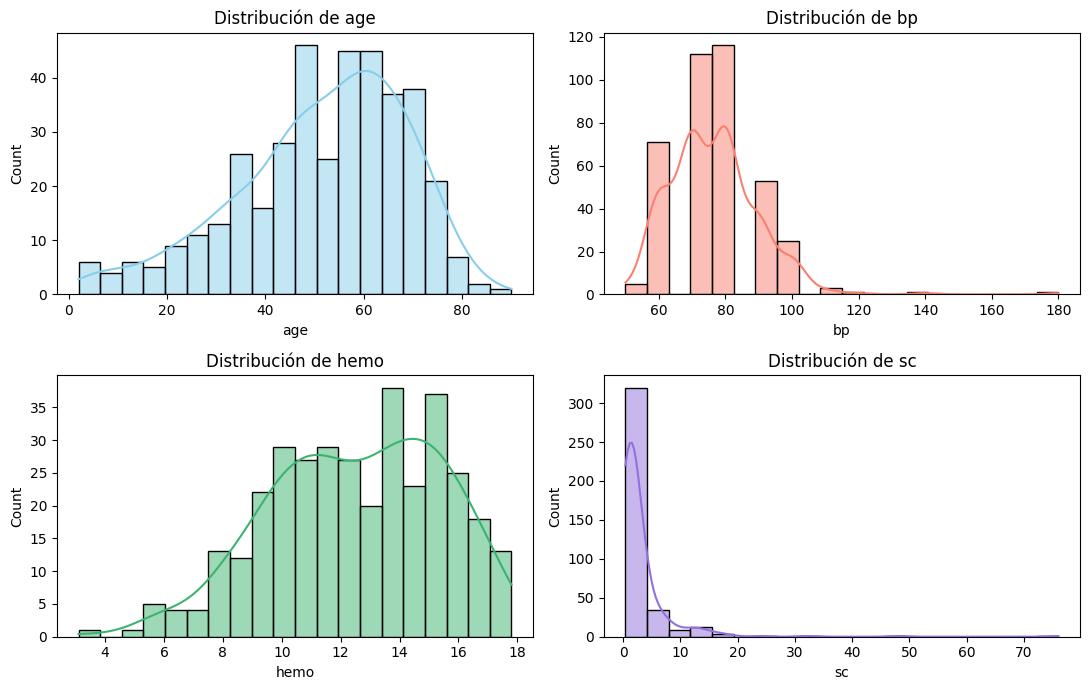

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, color in zip(
    axes.ravel(),
    ["age", "bp", "hemo", "sc"],
    ["skyblue", "salmon", "mediumseagreen", "mediumpurple"],
):
    sns.histplot(df[col], bins=20, kde=True, ax=ax, color=color)
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

**Interpretación:** `age` y `bp` muestran distribuciones razonablemente simétricas
alrededor de sus medias. `hemo` tiene una ligera asimetría hacia la izquierda (varios
pacientes con anemia marcada). `sc` es la más sesgada de las cuatro, con una cola larga hacia
la derecha por los casos de creatinina muy elevada, típicos de la enfermedad renal avanzada.
Esta asimetría de `sc` (y en menor medida `hemo`) refuerza la decisión de imputar con la
mediana en vez de la media.

## 5. Variables categóricas: categorías y posible orden

In [9]:
for col in ["rbc", "dm", "appet"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- rbc ---
rbc
normal      201
NaN         152
abnormal     47
Name: count, dtype: int64

--- dm ---
dm
no       258
yes      134
\tno       3
\tyes      2
NaN        2
 yes       1
Name: count, dtype: int64

--- appet ---
appet
good    317
poor     82
NaN       1
Name: count, dtype: int64



### 5.1 Categorías identificadas

- **`rbc`:** `normal`, `abnormal` — nominal, sin orden, 2 categorías (baja cardinalidad).
- **`dm`:** en teoría `yes`/`no`, pero el dato crudo trae variantes sucias: `' yes'`,
  `'\tno'`, `'\tyes'`, con espacios y tabulaciones que las separan de `'yes'`/`'no'` aunque
  representen la misma categoría. Nominal, sin orden, 2 categorías reales una vez limpio el
  texto.
- **`appet`:** `good`, `poor` — **categórica ordinal**, con orden clínico natural
  `poor < good` (peor a mejor apetito del paciente).

El caso de `dm` es el motivador concreto del *custom transformer* de la siguiente sección:
sin limpiar el texto, `'\tno'` quedaría como una categoría distinta de `'no'` al codificar.

## 6. Custom Transformer (`FunctionTransformer`)

Antes de codificar las variables categóricas hay que **limpiar el texto**: quitar
espacios en blanco y tabulaciones sobrantes (como en `'\tno'` o `' yes'` dentro de `dm`) y
normalizar a minúsculas, para que categorías equivalentes no queden separadas por errores de
formato del dataset original. Esto se implementa como una función libre envuelta en un
`FunctionTransformer`, cumpliendo el requisito de un *custom transformer* dentro del pipeline
de scikit-learn.

In [10]:
def limpiar_texto_categorico(X: pd.DataFrame) -> pd.DataFrame:
    """Limpia las columnas de texto de un DataFrame:
    quita espacios en blanco y tabulaciones al inicio/final, y normaliza a minusculas.
    Los NaN se preservan (no se convierten en el string "nan")."""
    X = X.copy()
    for col in X.columns:
        es_texto = (
            pd.api.types.is_object_dtype(X[col])
            or pd.api.types.is_string_dtype(X[col])
            or isinstance(X[col].dtype, pd.CategoricalDtype)
        )
        if es_texto:
            # se usa np.nan explicito (no pd.NA) para que SimpleImputer
            # identifique los faltantes sin ambiguedad
            X[col] = X[col].apply(
                lambda v: v.strip().lower() if isinstance(v, str) else np.nan
            )
    return X


limpieza_transformer = FunctionTransformer(limpiar_texto_categorico)

# Prueba rapida del transformer de forma aislada, sobre la columna sucia real (dm)
demo = df[["dm"]].copy()
print("Antes:", demo["dm"].unique())
print("Despues:", limpieza_transformer.transform(demo)["dm"].unique())

Antes: ['yes' 'no' ' yes' '\tno' '\tyes' nan]
Despues: ['yes' 'no' nan]


## 7. Pipeline de pre-procesamiento completo

In [11]:
num_cols = ["age", "bp", "hemo", "sc"]
cat_nom = ["rbc", "dm"]
cat_ord = ["appet"]
orden_appet = [["poor", "good"]]

# --- Sub-pipeline numérico ---
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# --- Sub-pipeline categórico nominal ---
cat_nom_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- Sub-pipeline categórico ordinal ---
cat_ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=orden_appet)),
])

preprocesador = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("nom", cat_nom_pipe, cat_nom),
    ("ord", cat_ord_pipe, cat_ord),
], remainder="drop", verbose_feature_names_out=False).set_output(transform="pandas")

# --- Pipeline completo: limpieza (custom) -> pre-procesamiento -> modelo ---
pipeline_completo = Pipeline([
    ("limpieza", limpieza_transformer),
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000)),
])

pipeline_completo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('limpieza', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function lim...0018FA5B1A700>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=Non

**`remainder="drop"`:** `id` ya se descartó al construir `cols_usar` (sección 2.1), así
que en este `ColumnTransformer` no hay columnas de sobra que decidir si conservar. Se deja
`remainder="drop"` explícito (en vez de `"passthrough"`) porque es el comportamiento correcto
si en algún momento se amplía `cols_usar` con otra variable clínica sin agregarla todavía a
`num_cols`/`cat_nom`/`cat_ord`: mejor que quede afuera de X a que entre sin transformar (por
ejemplo, una columna de texto sin codificar rompería el modelo en vez de dar un resultado
silenciosamente incorrecto).

**`set_output(transform="pandas")`:** por defecto un `ColumnTransformer` devuelve un array de
numpy sin nombres de columna. Con esta opción, `preprocesador.transform(...)` devuelve un
DataFrame con los nombres reales de cada feature generada (incluidas las columnas one-hot como
`rbc_normal`, `dm_yes`, etc.), lo que hace mucho más fácil inspeccionar qué le está entrando al
modelo.

In [12]:
# Vista del resultado del preprocesamiento (antes del modelo), con nombres de columna reales
X_limpio = limpieza_transformer.transform(df[cols_usar])
preprocesador.fit_transform(X_limpio).head()

,age,bp,hemo,sc,rbc_abnormal,rbc_normal,dm_no,dm_yes,appet
0,-0.210031,0.254214,1.053226,-0.319668,0.0,1.0,0.0,1.0,1.0
1,-2.627234,-1.972476,-0.457965,-0.390819,0.0,1.0,1.0,0.0,1.0
2,0.615355,0.254214,-1.084556,-0.212942,0.0,1.0,0.0,1.0,0.0
3,-0.210031,-0.488016,-0.494823,0.142813,0.0,1.0,1.0,0.0,0.0
4,-0.033163,0.254214,-0.347390,-0.284093,0.0,1.0,1.0,0.0,1.0


El pipeline encapsula tres etapas encadenadas:

1. **`limpieza`** — el custom `FunctionTransformer` que normaliza el texto de las columnas
   categóricas (`rbc`, `dm`, `appet`).
2. **`preprocesamiento`** — un `ColumnTransformer` que aplica, en paralelo, imputación +
   escalado a las numéricas, imputación + one-hot a `rbc`/`dm`, e imputación + codificación
   ordinal a `appet`.
3. **`modelo`** — un clasificador (`LogisticRegression`) para validar que el
   pre-procesamiento produce una matriz de features utilizable.

Al ser un único objeto `Pipeline`, garantiza que cualquier partición de datos (train/test, o
pacientes nuevos) pase exactamente por las mismas transformaciones, evitando fuga de
información (*data leakage*). Nótese que la etapa de `limpieza` recibe todo el DataFrame de
entrada, pero como internamente solo modifica columnas de tipo texto, no interfiere con las
columnas numéricas que procesa después el `ColumnTransformer`.

## 8. Entrenamiento y validación

In [13]:
X = df[cols_usar]
y = df[target].astype("string").str.strip()  # limpieza puntual del target ("ckd\t" -> "ckd")
print("Clases del target:", y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline_completo.fit(X_train, y_train)
y_pred = pipeline_completo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Clases del target: <StringArray>
['ckd', 'notckd']
Length: 2, dtype: string
Accuracy: 0.95

Matriz:
 [[49  1]
 [ 3 27]]

Reporte de clasificación:
               precision    recall  f1-score   support

         ckd       0.94      0.98      0.96        50
      notckd       0.96      0.90      0.93        30

    accuracy                           0.95        80
   macro avg       0.95      0.94      0.95        80
weighted avg       0.95      0.95      0.95        80



**Interpretación:** el objetivo principal de este trabajo es el diseño del pipeline de
pre-procesamiento, no maximizar el desempeño del modelo. Aun así, a diferencia de un dataset
sintético sin relación real entre variables, `kidney_disease.csv` es un dataset clínico real
donde `sc`, `hemo`, `bp` y `appet` están fuertemente asociados al diagnóstico de enfermedad
renal, así que el accuracy obtenido es alto. Lo relevante para la guía es que el pipeline corre
de principio a fin sin errores, maneja los datos faltantes de las siete columnas usadas,
limpia inconsistencias reales de texto (espacios y tabulaciones en `dm`) y produce una matriz
de features numérica lista para cualquier modelo de `scikit-learn`.

## 9. Conclusiones

- El subconjunto trabajado de `kidney_disease.csv` cumple las condiciones pedidas:
  mezcla de variables numéricas y categóricas (nominales y ordinales), baja cardinalidad en
  las categóricas nominales (2 categorías cada una), 7 variables predictoras y presencia real
  de datos faltantes en todas ellas (entre ~4% y ~38%).
- Se identificaron las estrategias de imputación (mediana para numéricas, moda para
  categóricas) y de escalamiento (`StandardScaler`) más adecuadas según la forma de las
  distribuciones, en particular la fuerte asimetría de `sc`.
- Se implementó un **Custom Transformer** mediante `FunctionTransformer` que limpia espacios
  en blanco y tabulaciones, y normaliza mayúsculas/minúsculas en las columnas de texto,
  resolviendo un problema real de calidad de datos detectado en `dm` (`'\tno'`, `' yes'`),
  no uno simulado.
- El pipeline final (`Pipeline` + `ColumnTransformer`) integra limpieza, imputación, escalado
  y codificación de todas las variables en un solo objeto reutilizable y evaluable con
  `scikit-learn`, y al validarlo con una Regresión Logística confirma que el diagnóstico de
  enfermedad renal está fuertemente asociado a las variables clínicas seleccionadas.